# Observabilidad en Agentes de IA: Práctica con Métricas y Monitoreo

## Objetivo
Implementar un sistema completo de observabilidad para un agente de IA, incluyendo recolección de métricas, logging estructurado, dashboards y alertas.

---

## ¿Por qué importa la observabilidad en agentes de IA?

Los agentes de IA en producción enfrentan desafíos únicos que hacen la observabilidad **crítica**:

- **Latencia**: Las llamadas a LLMs pueden variar significativamente en tiempo de respuesta (de 500ms a 30+ segundos). Sin monitoreo, los usuarios experimentan degradación silenciosa.
- **Errores**: Rate limits, timeouts, respuestas malformadas, alucinaciones — los modos de fallo son diversos y a menudo intermitentes.
- **Costos**: Cada token tiene un costo. Sin seguimiento granular, los costos pueden escalar rápidamente sin control.
- **Calidad**: A diferencia del software tradicional, la "corrección" de un agente de IA es subjetiva. Necesitamos métricas proxy para evaluar calidad.

### Los tres pilares de la observabilidad
1. **Métricas** — Datos numéricos agregados (latencia promedio, tasa de errores, tokens por minuto)
2. **Logs** — Registros detallados de eventos individuales
3. **Trazas** — Seguimiento del flujo completo de una solicitud a través del sistema

En este notebook nos enfocaremos en **métricas** y **logs estructurados**, construyendo un sistema de observabilidad desde cero.

## 0. Configuración del Entorno

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

for env_path in [Path.cwd() / ".env", *[parent / ".env" for parent in Path.cwd().parents]]:
    if env_path.exists():
        load_dotenv(env_path)
        break

if not os.getenv("GITHUB_TOKEN"):
    raise EnvironmentError("GITHUB_TOKEN no configurado. Copia .env.example a .env y agrega tu token.")
print("Entorno configurado correctamente")

Entorno configurado correctamente


In [2]:
# Importaciones generales
import time
import json
import uuid
import logging
from datetime import datetime, timezone
from dataclasses import dataclass, field, asdict
from typing import Optional
import statistics

import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Sistema de Métricas

Vamos a construir un **recolector de métricas** que registre datos clave de cada interacción con el agente. Usaremos `dataclasses` para modelar los registros de forma limpia.

In [3]:
@dataclass
class MetricaLlamada:
    """Registro de métricas para una llamada individual al LLM."""
    timestamp: str
    modelo: str
    tiempo_respuesta_ms: float
    tokens_prompt: int
    tokens_completion: int
    tokens_total: int
    costo_estimado_usd: float
    exitoso: bool
    tipo_error: Optional[str] = None
    mensaje_error: Optional[str] = None
    trace_id: str = field(default_factory=lambda: str(uuid.uuid4())[:8])


class RecolectorMetricas:
    """Recolector central de métricas para llamadas al LLM."""

    # Precios aproximados por 1M tokens (USD) - gpt-4o-mini
    PRECIOS = {
        "gpt-4o-mini": {"prompt": 0.15, "completion": 0.60},
        "gpt-4o": {"prompt": 2.50, "completion": 10.00},
    }

    def __init__(self):
        self.metricas: list[MetricaLlamada] = []

    def estimar_costo(self, modelo: str, tokens_prompt: int, tokens_completion: int) -> float:
        """Estima el costo en USD de una llamada basado en tokens usados."""
        precios = self.PRECIOS.get(modelo, self.PRECIOS["gpt-4o-mini"])
        costo_prompt = (tokens_prompt / 1_000_000) * precios["prompt"]
        costo_completion = (tokens_completion / 1_000_000) * precios["completion"]
        return round(costo_prompt + costo_completion, 8)

    def registrar_exito(self, modelo: str, tiempo_ms: float,
                        tokens_prompt: int, tokens_completion: int,
                        trace_id: str = None) -> MetricaLlamada:
        """Registra una llamada exitosa."""
        metrica = MetricaLlamada(
            timestamp=datetime.now(timezone.utc).isoformat(),
            modelo=modelo,
            tiempo_respuesta_ms=round(tiempo_ms, 2),
            tokens_prompt=tokens_prompt,
            tokens_completion=tokens_completion,
            tokens_total=tokens_prompt + tokens_completion,
            costo_estimado_usd=self.estimar_costo(modelo, tokens_prompt, tokens_completion),
            exitoso=True,
            trace_id=trace_id or str(uuid.uuid4())[:8]
        )
        self.metricas.append(metrica)
        return metrica

    def registrar_error(self, modelo: str, tiempo_ms: float,
                        tipo_error: str, mensaje_error: str,
                        trace_id: str = None) -> MetricaLlamada:
        """Registra una llamada fallida."""
        metrica = MetricaLlamada(
            timestamp=datetime.now(timezone.utc).isoformat(),
            modelo=modelo,
            tiempo_respuesta_ms=round(tiempo_ms, 2),
            tokens_prompt=0,
            tokens_completion=0,
            tokens_total=0,
            costo_estimado_usd=0.0,
            exitoso=False,
            tipo_error=tipo_error,
            mensaje_error=mensaje_error,
            trace_id=trace_id or str(uuid.uuid4())[:8]
        )
        self.metricas.append(metrica)
        return metrica

    def resumen(self) -> dict:
        """Genera un resumen estadístico de todas las métricas recolectadas."""
        if not self.metricas:
            return {"mensaje": "No hay métricas registradas"}

        exitosas = [m for m in self.metricas if m.exitoso]
        fallidas = [m for m in self.metricas if not m.exitoso]
        tiempos = [m.tiempo_respuesta_ms for m in exitosas]

        return {
            "total_llamadas": len(self.metricas),
            "exitosas": len(exitosas),
            "fallidas": len(fallidas),
            "tasa_error_pct": round(len(fallidas) / len(self.metricas) * 100, 2),
            "tiempo_promedio_ms": round(statistics.mean(tiempos), 2) if tiempos else 0,
            "tiempo_p50_ms": round(statistics.median(tiempos), 2) if tiempos else 0,
            "tiempo_p95_ms": round(sorted(tiempos)[int(len(tiempos) * 0.95)] if tiempos else 0, 2),
            "tiempo_max_ms": round(max(tiempos), 2) if tiempos else 0,
            "tokens_totales": sum(m.tokens_total for m in exitosas),
            "costo_total_usd": round(sum(m.costo_estimado_usd for m in exitosas), 6),
        }

    def a_dataframe(self) -> pd.DataFrame:
        """Convierte las métricas a un DataFrame de pandas."""
        return pd.DataFrame([asdict(m) for m in self.metricas])


# Instanciar el recolector global
recolector = RecolectorMetricas()
print("RecolectorMetricas creado exitosamente")
print(f"Modelos con precios configurados: {list(RecolectorMetricas.PRECIOS.keys())}")

RecolectorMetricas creado exitosamente
Modelos con precios configurados: ['gpt-4o-mini', 'gpt-4o']


---
## 2. Logging Estructurado

El logging tradicional produce líneas de texto libre que son difíciles de analizar programáticamente. El **logging estructurado** produce registros en formato JSON, lo que permite:
- Búsqueda y filtrado eficiente
- Correlación entre servicios mediante `trace_id`
- Análisis automatizado con herramientas como ELK Stack, Datadog, etc.

### Comparación: Logging Tradicional vs Estructurado

```
# Tradicional (difícil de parsear)
2026-03-12 10:30:45 INFO Llamada exitosa al modelo gpt-4o-mini en 1234ms, 150 tokens

# Estructurado (fácil de parsear y analizar)
{"timestamp": "2026-03-12T10:30:45Z", "level": "INFO", "event": "llm_call_success", 
 "model": "gpt-4o-mini", "duration_ms": 1234, "tokens": 150, "trace_id": "abc123"}
```

In [4]:
class LoggerEstructurado:
    """Logger que produce registros en formato JSON estructurado."""

    NIVELES = {
        "DEBUG": 10,
        "INFO": 20,
        "WARNING": 30,
        "ERROR": 40,
        "CRITICAL": 50
    }

    def __init__(self, nombre: str, nivel_minimo: str = "DEBUG"):
        self.nombre = nombre
        self.nivel_minimo = self.NIVELES.get(nivel_minimo, 10)
        self.registros: list[dict] = []

    def _registrar(self, nivel: str, evento: str, trace_id: str = None, **metadata):
        """Registra un evento estructurado."""
        if self.NIVELES.get(nivel, 0) < self.nivel_minimo:
            return

        registro = {
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "nivel": nivel,
            "logger": self.nombre,
            "evento": evento,
            "trace_id": trace_id or "sin-trace",
            **metadata
        }
        self.registros.append(registro)
        # Imprimir en formato JSON compacto
        print(json.dumps(registro, ensure_ascii=False, default=str))

    def debug(self, evento: str, trace_id: str = None, **kwargs):
        self._registrar("DEBUG", evento, trace_id, **kwargs)

    def info(self, evento: str, trace_id: str = None, **kwargs):
        self._registrar("INFO", evento, trace_id, **kwargs)

    def warning(self, evento: str, trace_id: str = None, **kwargs):
        self._registrar("WARNING", evento, trace_id, **kwargs)

    def error(self, evento: str, trace_id: str = None, **kwargs):
        self._registrar("ERROR", evento, trace_id, **kwargs)

    def critical(self, evento: str, trace_id: str = None, **kwargs):
        self._registrar("CRITICAL", evento, trace_id, **kwargs)

    def obtener_registros(self, nivel: str = None, trace_id: str = None) -> list[dict]:
        """Filtra registros por nivel y/o trace_id."""
        resultado = self.registros
        if nivel:
            resultado = [r for r in resultado if r["nivel"] == nivel]
        if trace_id:
            resultado = [r for r in resultado if r["trace_id"] == trace_id]
        return resultado


# Crear logger global
logger = LoggerEstructurado("agente-observable")
print("Logger estructurado creado")

Logger estructurado creado


In [5]:
# Demostración de los distintos niveles de log
print("=== Demostración de niveles de logging ===")
print()

demo_trace = str(uuid.uuid4())[:8]

logger.debug("inicio_procesamiento", trace_id=demo_trace, query="test")
print()
logger.info("llamada_api_exitosa", trace_id=demo_trace, modelo="gpt-4o-mini", duracion_ms=1250)
print()
logger.warning("latencia_alta", trace_id=demo_trace, duracion_ms=5200, umbral_ms=3000)
print()
logger.error("llamada_api_fallida", trace_id=demo_trace, tipo_error="RateLimitError", intentos=3)
print()

print(f"\nTotal de registros almacenados: {len(logger.registros)}")

# Limpiar registros de demostración para no contaminar las métricas reales
logger.registros.clear()

=== Demostración de niveles de logging ===

{"timestamp": "2026-05-27T00:08:43.490695+00:00", "nivel": "DEBUG", "logger": "agente-observable", "evento": "inicio_procesamiento", "trace_id": "66f14d78", "query": "test"}

{"timestamp": "2026-05-27T00:08:43.491558+00:00", "nivel": "INFO", "logger": "agente-observable", "evento": "llamada_api_exitosa", "trace_id": "66f14d78", "modelo": "gpt-4o-mini", "duracion_ms": 1250}

{"timestamp": "2026-05-27T00:08:43.491746+00:00", "nivel": "WARNING", "logger": "agente-observable", "evento": "latencia_alta", "trace_id": "66f14d78", "duracion_ms": 5200, "umbral_ms": 3000}

{"timestamp": "2026-05-27T00:08:43.491853+00:00", "nivel": "ERROR", "logger": "agente-observable", "evento": "llamada_api_fallida", "trace_id": "66f14d78", "tipo_error": "RateLimitError", "intentos": 3}


Total de registros almacenados: 4


---
## 3. Agente Observable

Ahora combinamos el **recolector de métricas** y el **logger estructurado** en un agente que automáticamente registra toda su actividad.

In [6]:
class AgenteObservable:
    """Agente de IA con observabilidad integrada.
    
    Cada interacción se registra automáticamente con:
    - Trace ID único para correlación
    - Métricas de rendimiento (latencia, tokens, costo)
    - Logs estructurados de cada paso
    """

    def __init__(self, modelo: str = "gpt-4o-mini",
                 recolector: RecolectorMetricas = None,
                 logger: LoggerEstructurado = None):
        self.modelo = modelo
        self.recolector = recolector or RecolectorMetricas()
        self.logger = logger or LoggerEstructurado("agente-observable")
        self.client = OpenAI(
            base_url=os.getenv("GITHUB_BASE_URL") or os.getenv("OPENAI_BASE_URL", "https://models.inference.ai.azure.com"),
            api_key=os.getenv("GITHUB_TOKEN"),
            timeout=30,
        )
        self.historial_conversacion = []
        self.logger.info("agente_inicializado", modelo=self.modelo)

    def consultar(self, mensaje: str, system_prompt: str = None,
                  temperatura: float = 0.7, max_tokens: int = 500) -> dict:
        """Realiza una consulta al LLM con observabilidad completa.
        
        Retorna un diccionario con la respuesta y metadatos de observabilidad.
        """
        trace_id = str(uuid.uuid4())[:8]

        # Log: inicio de la consulta
        self.logger.info("consulta_iniciada", trace_id=trace_id,
                         largo_mensaje=len(mensaje),
                         temperatura=temperatura,
                         max_tokens=max_tokens)

        # Construir mensajes
        mensajes = []
        if system_prompt:
            mensajes.append({"role": "system", "content": system_prompt})
        mensajes.append({"role": "user", "content": mensaje})

        # Realizar la llamada con medición de tiempo
        inicio = time.perf_counter()
        try:
            respuesta = self.client.chat.completions.create(
                model=self.modelo,
                messages=mensajes,
                temperature=temperatura,
                max_tokens=max_tokens
            )
            fin = time.perf_counter()
            tiempo_ms = (fin - inicio) * 1000

            # Extraer datos de uso
            tokens_prompt = respuesta.usage.prompt_tokens
            tokens_completion = respuesta.usage.completion_tokens
            contenido = respuesta.choices[0].message.content

            # Registrar métrica de éxito
            metrica = self.recolector.registrar_exito(
                modelo=self.modelo,
                tiempo_ms=tiempo_ms,
                tokens_prompt=tokens_prompt,
                tokens_completion=tokens_completion,
                trace_id=trace_id
            )

            # Log: éxito
            self.logger.info("consulta_exitosa", trace_id=trace_id,
                             tiempo_ms=round(tiempo_ms, 2),
                             tokens_prompt=tokens_prompt,
                             tokens_completion=tokens_completion,
                             costo_usd=metrica.costo_estimado_usd)

            return {
                "respuesta": contenido,
                "trace_id": trace_id,
                "tiempo_ms": round(tiempo_ms, 2),
                "tokens_total": tokens_prompt + tokens_completion,
                "costo_usd": metrica.costo_estimado_usd,
                "exitoso": True
            }

        except Exception as e:
            fin = time.perf_counter()
            tiempo_ms = (fin - inicio) * 1000
            tipo_error = type(e).__name__

            # Registrar métrica de error
            self.recolector.registrar_error(
                modelo=self.modelo,
                tiempo_ms=tiempo_ms,
                tipo_error=tipo_error,
                mensaje_error=str(e),
                trace_id=trace_id
            )

            # Log: error
            self.logger.error("consulta_fallida", trace_id=trace_id,
                              tiempo_ms=round(tiempo_ms, 2),
                              tipo_error=tipo_error,
                              mensaje_error=str(e)[:200])

            return {
                "respuesta": None,
                "trace_id": trace_id,
                "tiempo_ms": round(tiempo_ms, 2),
                "tokens_total": 0,
                "costo_usd": 0,
                "exitoso": False,
                "error": str(e)
            }


# Crear el agente observable
agente = AgenteObservable(
    modelo="gpt-4o-mini",
    recolector=recolector,
    logger=logger
)
print("Agente observable creado y listo")

{"timestamp": "2026-05-27T00:09:43.949501+00:00", "nivel": "INFO", "logger": "agente-observable", "evento": "agente_inicializado", "trace_id": "sin-trace", "modelo": "gpt-4o-mini"}
Agente observable creado y listo


In [7]:
# Prueba básica del agente
resultado = agente.consultar(
    "Explica en 2 oraciones qué es la observabilidad en sistemas de software.",
    system_prompt="Eres un experto en ingeniería de software. Responde de forma concisa en español."
)

print("\n" + "="*60)
print(f"Trace ID: {resultado['trace_id']}")
print(f"Tiempo: {resultado['tiempo_ms']}ms")
print(f"Tokens: {resultado['tokens_total']}")
print(f"Costo: ${resultado['costo_usd']}")
print(f"\nRespuesta: {resultado['respuesta']}")

{"timestamp": "2026-05-27T00:10:17.481903+00:00", "nivel": "INFO", "logger": "agente-observable", "evento": "consulta_iniciada", "trace_id": "1f3242bd", "largo_mensaje": 72, "temperatura": 0.7, "max_tokens": 500}
{"timestamp": "2026-05-27T00:10:21.166245+00:00", "nivel": "ERROR", "logger": "agente-observable", "evento": "consulta_fallida", "trace_id": "1f3242bd", "tiempo_ms": 3680.28, "tipo_error": "RateLimitError", "mensaje_error": "Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 300 per 86400s exceeded for UserByModelByDay. Please wait 51004 seconds before retrying.', 'details': 'Rate limit of "}

Trace ID: 1f3242bd
Tiempo: 3680.28ms
Tokens: 0
Costo: $0

Respuesta: None


In [8]:
# Ejecutar múltiples consultas para generar métricas
consultas = [
    "¿Qué es un LLM y cómo funciona?",
    "Explica el patrón RAG en 3 oraciones.",
    "¿Cuáles son las ventajas de usar agentes de IA?",
    "Describe el concepto de prompt engineering.",
    "¿Qué es el fine-tuning de modelos?",
    "Explica la diferencia entre GPT y BERT.",
    "¿Qué son los embeddings en NLP?",
    "¿Cómo funciona la atención en transformers?",
    "Describe el concepto de chain-of-thought.",
    "¿Qué es la temperatura en generación de texto?",
    "Explica qué es un token en el contexto de LLMs.",
    "¿Cuáles son los riesgos de las alucinaciones en IA?"
]

system_prompt = "Eres un asistente experto en IA. Responde de forma concisa en español, máximo 3 oraciones."

print(f"Ejecutando {len(consultas)} consultas...\n")

resultados = []
for i, consulta in enumerate(consultas, 1):
    print(f"--- Consulta {i}/{len(consultas)}: {consulta[:50]}...")
    resultado = agente.consultar(consulta, system_prompt=system_prompt, max_tokens=200)
    resultados.append(resultado)
    estado = "OK" if resultado["exitoso"] else "ERROR"
    print(f"    [{estado}] {resultado['tiempo_ms']}ms | {resultado['tokens_total']} tokens\n")

print(f"\nCompletadas: {sum(1 for r in resultados if r['exitoso'])}/{len(consultas)}")

Ejecutando 12 consultas...

--- Consulta 1/12: ¿Qué es un LLM y cómo funciona?...
{"timestamp": "2026-05-27T00:11:17.943878+00:00", "nivel": "INFO", "logger": "agente-observable", "evento": "consulta_iniciada", "trace_id": "c7bc5c97", "largo_mensaje": 31, "temperatura": 0.7, "max_tokens": 200}
{"timestamp": "2026-05-27T00:11:20.409569+00:00", "nivel": "ERROR", "logger": "agente-observable", "evento": "consulta_fallida", "trace_id": "c7bc5c97", "tiempo_ms": 2465.46, "tipo_error": "RateLimitError", "mensaje_error": "Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 300 per 86400s exceeded for UserByModelByDay. Please wait 50945 seconds before retrying.', 'details': 'Rate limit of "}
    [ERROR] 2465.46ms | 0 tokens

--- Consulta 2/12: Explica el patrón RAG en 3 oraciones....
{"timestamp": "2026-05-27T00:11:20.412188+00:00", "nivel": "INFO", "logger": "agente-observable", "evento": "consulta_iniciada", "trace_id": "c36af5c4", "largo_mensaje": 37, "temperat

---
## 4. Dashboard de Métricas

Con los datos recolectados, generaremos visualizaciones que permitan entender el comportamiento del agente.

In [9]:
# Ver resumen estadístico
resumen = recolector.resumen()
print("=== RESUMEN DE MÉTRICAS ===")
for clave, valor in resumen.items():
    print(f"  {clave}: {valor}")

=== RESUMEN DE MÉTRICAS ===
  total_llamadas: 13
  exitosas: 0
  fallidas: 13
  tasa_error_pct: 100.0
  tiempo_promedio_ms: 0
  tiempo_p50_ms: 0
  tiempo_p95_ms: 0
  tiempo_max_ms: 0
  tokens_totales: 0
  costo_total_usd: 0


In [10]:
# Obtener DataFrame para análisis
df_metricas = recolector.a_dataframe()
print(f"Registros totales: {len(df_metricas)}")
df_metricas.head()

Registros totales: 13


,timestamp,modelo,tiempo_respuesta_ms,tokens_prompt,tokens_completion,tokens_total,costo_estimado_usd,exitoso,tipo_error,mensaje_error,trace_id
0,2026-05-27T00:10:21.163793+00:00,gpt-4o-mini,3680.28,0,0,0,0.0,False,RateLimitError,Error code: 429 - {'error': {'code': 'RateLimi...,1f3242bd
1,2026-05-27T00:11:20.409481+00:00,gpt-4o-mini,2465.46,0,0,0,0.0,False,RateLimitError,Error code: 429 - {'error': {'code': 'RateLimi...,c7bc5c97
2,2026-05-27T00:11:22.084659+00:00,gpt-4o-mini,1672.35,0,0,0,0.0,False,RateLimitError,Error code: 429 - {'error': {'code': 'RateLimi...,c36af5c4
3,2026-05-27T00:11:23.940588+00:00,gpt-4o-mini,1855.54,0,0,0,0.0,False,RateLimitError,Error code: 429 - {'error': {'code': 'RateLimi...,3c88c756
4,2026-05-27T00:11:25.730828+00:00,gpt-4o-mini,1788.65,0,0,0,0.0,False,RateLimitError,Error code: 429 - {'error': {'code': 'RateLimi...,717e8533


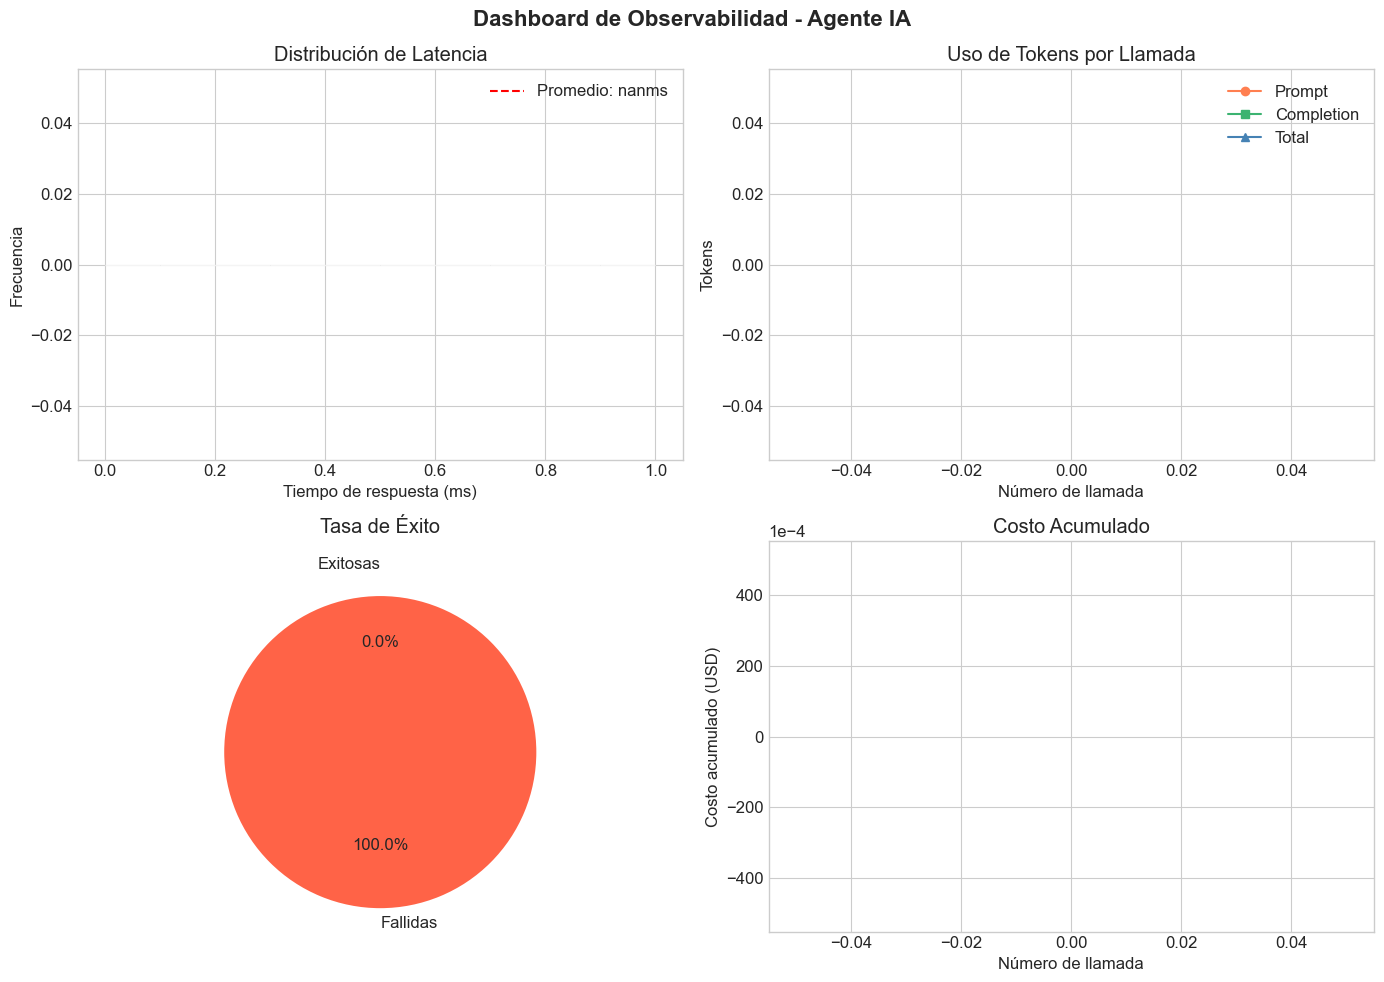

In [11]:
# Dashboard de métricas: 4 gráficos
df_exitosas = df_metricas[df_metricas["exitoso"] == True].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dashboard de Observabilidad - Agente IA", fontsize=16, fontweight="bold")

# 1. Distribución de tiempo de respuesta (histograma)
ax1 = axes[0, 0]
ax1.hist(df_exitosas["tiempo_respuesta_ms"], bins=10, color="steelblue", edgecolor="white", alpha=0.8)
ax1.axvline(df_exitosas["tiempo_respuesta_ms"].mean(), color="red", linestyle="--",
            label=f"Promedio: {df_exitosas['tiempo_respuesta_ms'].mean():.0f}ms")
ax1.set_xlabel("Tiempo de respuesta (ms)")
ax1.set_ylabel("Frecuencia")
ax1.set_title("Distribución de Latencia")
ax1.legend()

# 2. Uso de tokens por llamada (línea)
ax2 = axes[0, 1]
indices = range(1, len(df_exitosas) + 1)
ax2.plot(indices, df_exitosas["tokens_prompt"].values, marker="o", label="Prompt", color="coral")
ax2.plot(indices, df_exitosas["tokens_completion"].values, marker="s", label="Completion", color="mediumseagreen")
ax2.plot(indices, df_exitosas["tokens_total"].values, marker="^", label="Total", color="steelblue")
ax2.set_xlabel("Número de llamada")
ax2.set_ylabel("Tokens")
ax2.set_title("Uso de Tokens por Llamada")
ax2.legend()

# 3. Tasa de éxito vs error (pie)
ax3 = axes[1, 0]
exitosas = len(df_metricas[df_metricas["exitoso"] == True])
fallidas = len(df_metricas[df_metricas["exitoso"] == False])
if fallidas > 0:
    ax3.pie([exitosas, fallidas], labels=["Exitosas", "Fallidas"],
            colors=["mediumseagreen", "tomato"], autopct="%1.1f%%",
            startangle=90, explode=[0, 0.1])
else:
    ax3.pie([exitosas], labels=["Exitosas"],
            colors=["mediumseagreen"], autopct="%1.1f%%", startangle=90)
ax3.set_title("Tasa de Éxito")

# 4. Costo acumulado (línea)
ax4 = axes[1, 1]
costo_acumulado = df_exitosas["costo_estimado_usd"].cumsum()
ax4.fill_between(indices, costo_acumulado.values, alpha=0.3, color="goldenrod")
ax4.plot(indices, costo_acumulado.values, marker="o", color="goldenrod", linewidth=2)
ax4.set_xlabel("Número de llamada")
ax4.set_ylabel("Costo acumulado (USD)")
ax4.set_title("Costo Acumulado")
ax4.ticklabel_format(style='scientific', axis='y', scilimits=(-4, -4))

plt.tight_layout()
plt.show()

In [12]:
# Tabla resumen detallada con pandas
if not df_exitosas.empty:
    resumen_tabla = pd.DataFrame({
        "Métrica": [
            "Tiempo promedio (ms)",
            "Tiempo mediana (ms)",
            "Tiempo máximo (ms)",
            "Tiempo mínimo (ms)",
            "Desv. estándar tiempo (ms)",
            "Tokens promedio por llamada",
            "Tokens totales consumidos",
            "Costo promedio por llamada (USD)",
            "Costo total (USD)",
            "Tasa de éxito (%)"
        ],
        "Valor": [
            f"{df_exitosas['tiempo_respuesta_ms'].mean():.2f}",
            f"{df_exitosas['tiempo_respuesta_ms'].median():.2f}",
            f"{df_exitosas['tiempo_respuesta_ms'].max():.2f}",
            f"{df_exitosas['tiempo_respuesta_ms'].min():.2f}",
            f"{df_exitosas['tiempo_respuesta_ms'].std():.2f}",
            f"{df_exitosas['tokens_total'].mean():.1f}",
            f"{df_exitosas['tokens_total'].sum()}",
            f"${df_exitosas['costo_estimado_usd'].mean():.8f}",
            f"${df_exitosas['costo_estimado_usd'].sum():.6f}",
            f"{(exitosas / len(df_metricas) * 100):.1f}%"
        ]
    })
    print("=== TABLA RESUMEN DE RENDIMIENTO ===")
    print(resumen_tabla.to_string(index=False))

---
## 5. Alertas y Umbrales

Un sistema de observabilidad no está completo sin **alertas**. Definimos reglas que disparan notificaciones cuando las métricas superan umbrales definidos.

In [14]:
@dataclass
class ReglaAlerta:
    """Define una regla de alerta con umbral y condición."""
    nombre: str
    descripcion: str
    umbral: float
    tipo: str  # "latencia_ms", "tasa_error_pct", "tokens_totales", "costo_usd"


@dataclass
class Alerta:
    """Alerta disparada cuando se supera un umbral."""
    timestamp: str
    regla: str
    severidad: str  # WARNING, CRITICAL
    valor_actual: float
    umbral: float
    mensaje: str


class SistemaAlertas:
    """Sistema de alertas basado en reglas y umbrales."""

    def __init__(self, recolector: RecolectorMetricas, logger: LoggerEstructurado):
        self.recolector = recolector
        self.logger = logger
        self.reglas: list[ReglaAlerta] = []
        self.alertas_disparadas: list[Alerta] = []

    def agregar_regla(self, regla: ReglaAlerta):
        """Agrega una regla de alerta al sistema."""
        self.reglas.append(regla)

    def evaluar(self) -> list[Alerta]:
        """Evalúa todas las reglas contra las métricas actuales."""
        nuevas_alertas = []
        resumen = self.recolector.resumen()

        for regla in self.reglas:
            valor_actual = None

            if regla.tipo == "latencia_ms":
                valor_actual = resumen.get("tiempo_p95_ms", 0)
            elif regla.tipo == "tasa_error_pct":
                valor_actual = resumen.get("tasa_error_pct", 0)
            elif regla.tipo == "tokens_totales":
                valor_actual = resumen.get("tokens_totales", 0)
            elif regla.tipo == "costo_usd":
                valor_actual = resumen.get("costo_total_usd", 0)

            if valor_actual is not None and valor_actual > regla.umbral:
                severidad = "CRITICAL" if valor_actual > regla.umbral * 1.5 else "WARNING"
                alerta = Alerta(
                    timestamp=datetime.now(timezone.utc).isoformat(),
                    regla=regla.nombre,
                    severidad=severidad,
                    valor_actual=round(valor_actual, 4),
                    umbral=regla.umbral,
                    mensaje=f"{regla.descripcion}. Valor actual: {valor_actual:.4f}, Umbral: {regla.umbral}"
                )
                nuevas_alertas.append(alerta)
                self.alertas_disparadas.append(alerta)

                # Registrar en el logger
                log_fn = self.logger.critical if severidad == "CRITICAL" else self.logger.warning
                log_fn("alerta_disparada",
                       regla=regla.nombre,
                       severidad=severidad,
                       valor_actual=round(valor_actual, 4),
                       umbral=regla.umbral)

        return nuevas_alertas


# Configurar el sistema de alertas
sistema_alertas = SistemaAlertas(recolector, logger)

# Definir reglas
sistema_alertas.agregar_regla(ReglaAlerta(
    nombre="latencia_alta",
    descripcion="La latencia P95 supera el umbral",
    umbral=5000,  # 5 segundos
    tipo="latencia_ms"
))

sistema_alertas.agregar_regla(ReglaAlerta(
    nombre="tasa_error_alta",
    descripcion="La tasa de errores supera el umbral",
    umbral=10.0,  # 10%
    tipo="tasa_error_pct"
))

sistema_alertas.agregar_regla(ReglaAlerta(
    nombre="presupuesto_tokens",
    descripcion="El uso total de tokens supera el presupuesto",
    umbral=5000,  # tokens
    tipo="tokens_totales"
))

sistema_alertas.agregar_regla(ReglaAlerta(
    nombre="presupuesto_costo",
    descripcion="El costo total supera el presupuesto",
    umbral=0.01,  # USD
    tipo="costo_usd"
))

print(f"Sistema de alertas configurado con {len(sistema_alertas.reglas)} reglas")

Sistema de alertas configurado con 4 reglas


In [15]:
# Evaluar las alertas con las métricas actuales
print("=== EVALUACIÓN DE ALERTAS ===")
print()

alertas = sistema_alertas.evaluar()

if alertas:
    print(f"\n¡Se dispararon {len(alertas)} alertas!\n")
    for alerta in alertas:
        icono = "[CRITICAL]" if alerta.severidad == "CRITICAL" else "[WARNING] "
        print(f"  {icono} {alerta.regla}: {alerta.mensaje}")
else:
    print("No se dispararon alertas. Todos los valores están dentro de los umbrales.")

print(f"\nTotal alertas históricas: {len(sistema_alertas.alertas_disparadas)}")

=== EVALUACIÓN DE ALERTAS ===

{"timestamp": "2026-05-27T00:14:23.293989+00:00", "nivel": "CRITICAL", "logger": "agente-observable", "evento": "alerta_disparada", "trace_id": "sin-trace", "regla": "tasa_error_alta", "severidad": "CRITICAL", "valor_actual": 100.0, "umbral": 10.0}

¡Se dispararon 1 alertas!

  [CRITICAL] tasa_error_alta: La tasa de errores supera el umbral. Valor actual: 100.0000, Umbral: 10.0

Total alertas históricas: 1


---
## 6. Ejercicio Práctico

### Instrucciones

1. **Ejecutar consultas adicionales**: Usa el `agente` para hacer al menos 10 consultas más con temas variados (preguntas técnicas, creativas, de análisis, etc.)
2. **Generar el dashboard**: Ejecuta las celdas del dashboard para visualizar las métricas actualizadas
3. **Analizar alertas**: Evalúa si se disparan alertas con los nuevos datos
4. **Reflexión**: En la celda de abajo, escribe tus observaciones sobre:
   - ¿Cuál fue la latencia promedio?
   - ¿Hubo alguna llamada inusualmente lenta?
   - ¿Cuántos tokens se consumieron en total?
   - ¿Se dispararon alertas? ¿Por qué?

In [ ]:
# === TU CÓDIGO AQUÍ ===
# Ejecuta al menos 10 consultas adicionales al agente

mis_consultas = [
    # Agrega tus consultas aquí
    # "¿Qué es el aprendizaje por refuerzo?",
    # "Explica el concepto de redes neuronales convolucionales.",
    # ...
]

for consulta in mis_consultas:
    resultado = agente.consultar(consulta, max_tokens=200)
    print(f"[{resultado['trace_id']}] {resultado['tiempo_ms']}ms - {consulta[:50]}")

# Después de ejecutar tus consultas, vuelve a correr las celdas del dashboard y alertas

### Reflexión

*Escribe aquí tus observaciones sobre las métricas observadas:*

- Latencia promedio: ...
- Llamadas lentas: ...
- Tokens consumidos: ...
- Alertas disparadas: ...
- Patrones observados: ...

---
## Resumen

En este notebook implementamos un sistema completo de observabilidad:

| Componente | Descripción |
|---|---|
| **RecolectorMetricas** | Registra latencia, tokens, costos y errores por cada llamada |
| **LoggerEstructurado** | Produce logs en formato JSON con trace_id para correlación |
| **AgenteObservable** | Wrapper que integra métricas y logging en cada interacción |
| **Dashboard** | Visualizaciones con matplotlib para análisis de rendimiento |
| **SistemaAlertas** | Reglas y umbrales para detección proactiva de problemas |

### Conceptos clave
- La observabilidad es fundamental para operar agentes de IA en producción
- Los logs estructurados (JSON) permiten análisis automatizado
- Los trace IDs permiten correlacionar eventos a través del sistema
- Las alertas basadas en umbrales permiten detectar problemas antes de que impacten al usuario
- Las métricas de costo son esenciales para controlar el presupuesto de uso de LLMs